The notebook shows:
- **Exploratory Data Analysis**
- **The data cleaning process before saving the data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

import sys
sys.path.insert(0, '..')

#### Exploratory Data Analysis (EDA)

**EDA** is the initial step in a data workflow to understand a given dataset before deciding on the following steps to take. This allows a data professional to formulate an idea of the dataset and how best to use it to achieve their project goals.

This usually involves understanding the type of data given, evaluating which data is important in achieving the project goals, identifying missing values or anomalies and how to handle them, and visualization to discover trends or patterns in the data.
___

The df.info(), df.head() methods, and the df.shape attribute allows us to to get an initial understanding of our dataset.

In [2]:
# download raw data from yahoo finance
data = yf.download('5296.KL', start='2023-01-01', end='2026-01-03', multi_level_index=False)
data.head(10) # view first 10 rows of data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,1.843226,1.861658,1.824794,1.843226,1624100
2023-01-04,1.834010,1.880091,1.834010,1.843226,1706800
2023-01-05,1.834010,1.843226,1.824794,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,1.843226,3364000
2023-01-09,1.898523,1.898523,1.880091,1.880091,3771500
2023-01-10,1.880091,1.898523,1.861658,1.898523,6016600
2023-01-11,1.815578,1.898523,1.806362,1.889307,9782000
2023-01-12,1.815578,1.824794,1.806362,1.824794,7753900
2023-01-13,1.806362,1.824794,1.806362,1.824794,5168400


The .info() method above gives an overview of the raw data:  
- 736 entries from 2023-01-03 to 2026-01-02
- No empty values in data
- data types are float and ints

In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 736 entries, 2023-01-03 to 2026-01-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   736 non-null    float64
 1   High    736 non-null    float64
 2   Low     736 non-null    float64
 3   Open    736 non-null    float64
 4   Volume  736 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [4]:
print(f"Shape of data: {data.shape}") # confirms information above, 736 rows, and 5 columns

Shape of data: (736, 5)


For financial applications, data is usually self-explanatory. Here:
- *Close*, the daily closing price of an asset
- *High*, the daily high of the trading price of an asset
- *Low*, the daily low of the trading price of an asset
- *Open*, the daily opening price of an asset
- *Volume*, the daily trading volume of an asset

#### Plot the daily closing price of MRDIY

For our project of predicting the next day price, the daily closing price *Close* is of main interest. Visualizing it is a natural next step to see its trend.

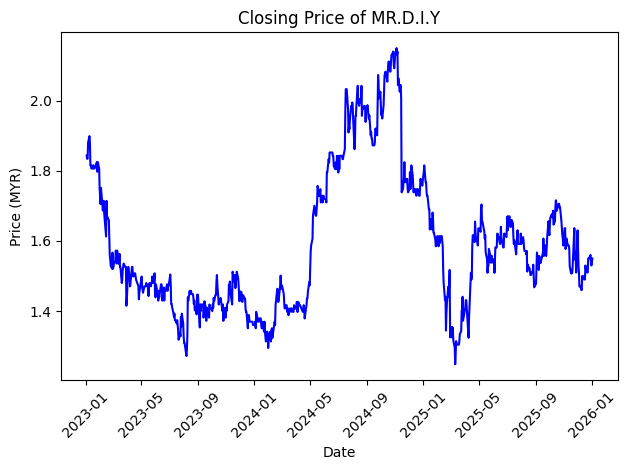

In [5]:
plt.figure()
plt.plot(data.index, data['Close'], color='b')
plt.title('Closing Price of MR.D.I.Y')
plt.ylabel('Price (MYR)')
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The price seems to be in a ranging state, with occasional runaway uptrends and downtrends. Perhaps for a more advanced project, we can try to utilize this property. However, for this project, an idea of how the price action behaves is sufficient.
___

A standardized API like Yahoo Finance usually provides clean and expected data for reproducability in a working data pipeline.

However, not all data ingestion methods give structured and cleaned data and thus may need additional data cleaning or pre-processing steps before being used in model training.

As I already know beforehand that I will be doing feature engineering with technical indicators, model outliers and anomalies will be dealt with together in the next notebook.

No further cleaning to be done here.

#### Save the dataset as a csv file

All features besides *Open* is saved here as our primary dataset for further processing.

In [6]:
# Features to be stored
features = ['Close', 'High', 'Low', 'Volume']

df = data[features].dropna().rename(
    columns={
        'Close':'close',
        'High':'high',
        'Low':'low',
        'Volume':'volume'
    }
)
df.head()

,close,high,low,volume
Date,,,,
2023-01-03,1.843226,1.861658,1.824794,1624100
2023-01-04,1.834010,1.880091,1.834010,1706800
2023-01-05,1.834010,1.843226,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,3364000
2023-01-09,1.898523,1.898523,1.880091,3771500


In [7]:
df.to_csv("../data/data.csv")